In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind
from scipy.stats import pearsonr

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")
sns.set_style("whitegrid")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

trader = pd.read_csv("historical_data.csv")

fear = pd.read_csv("fear_greed_index.csv")

print("Trader Dataset Shape :", trader.shape)
print("Fear & Greed Shape :", fear.shape)

print(trader.head())

print(fear.head())

print(trader.info())

print(fear.info())

print(trader.describe(include='all'))

print(fear.describe(include='all'))

print("\nMissing Values in Trader Dataset\n")
print(trader.isnull().sum())

print("\nMissing Values in Fear Dataset\n")
print(fear.isnull().sum())

print("Duplicate Rows Trader :", trader.duplicated().sum())

print("Duplicate Rows Fear :", fear.duplicated().sum())

trader.drop_duplicates(inplace=True)

fear.drop_duplicates(inplace=True)

print(trader.dtypes)

print(fear.dtypes)

trader["Timestamp"] = pd.to_datetime(
    trader["Timestamp"],
    errors="coerce"
)

fear["date"] = pd.to_datetime(
    fear["date"],
    errors="coerce"
)

trader["Trade_Date"] = trader["Timestamp"].dt.date

fear["Trade_Date"] = fear["date"].dt.date
print("Trader Start Date :", trader["Trade_Date"].min())

print("Trader End Date :", trader["Trade_Date"].max())

print("Fear Start Date :", fear["Trade_Date"].min())

print("Fear End Date :", fear["Trade_Date"].max())

trader["Hour"] = trader["Timestamp"].dt.hour

trader["Month"] = trader["Timestamp"].dt.month

trader["Year"] = trader["Timestamp"].dt.year

trader["Weekday"] = trader["Timestamp"].dt.day_name()

trader["Profit"] = np.where(
    trader["Closed PnL"] > 0,
    1,
    0
)

trader["Loss"] = np.where(
    trader["Closed PnL"] <= 0,
    1,
    0
)

trader["AbsolutePnL"] = trader["Closed PnL"].abs()


trader["NetPnL"] = trader["Closed PnL"] - trader["Fee"]

trader["TradeCategory"] = pd.qcut(
    trader["Size USD"],
    q=4,
    labels=[
        "Small",
        "Medium",
        "Large",
        "Very Large"
    ]
)

merged = pd.merge(
    trader,
    fear[
        [
            "Trade_Date",
            "classification",
            "value"
        ]
    ],
    on="Trade_Date",
    how="left"
)

print(merged.head())

print(merged.shape)

merged.rename(
    columns={
        "classification":"Sentiment",
        "value":"FearGreedValue"
    },
    inplace=True
)

print(merged["Sentiment"].value_counts())


merged.to_csv(
    "merged_data.csv",
    index=False
)

print("Merged Dataset Saved Successfully")

print("\nSummary Statistics")

print(merged.describe())

print(
    merged["Coin"].value_counts()
)

print(
    merged["Side"].value_counts()
)

print(
    merged["Sentiment"].value_counts()
)

print(
    merged["Coin"].value_counts().head(10)
)


print(
merged["Account"].value_counts().head(10)
)

print("\nDATA CLEANING COMPLETE")

Trader Dataset Shape : (211224, 16)
Fear & Greed Shape : (2644, 4)
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                        

Shape : (211224, 28)

Columns:

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'Trade_Date', 'Hour', 'Month', 'Year', 'Weekday', 'Profit',
       'Loss', 'AbsolutePnL', 'NetPnL', 'TradeCategory', 'Sentiment',
       'FearGreedValue'],
      dtype='object')

First Five Rows


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Trade_Date,Hour,Month,Year,Weekday,Profit,Loss,AbsolutePnL,NetPnL,TradeCategory,Sentiment,FearGreedValue
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1970-01-01 00:28:50,1970-01-01,0,1,1970,Thursday,0,1,0.0,-0.345404,Very Large,NaN,NaN
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1970-01-01 00:28:50,1970-01-01,0,1,1970,Thursday,0,1,0.0,-0.005600,Small,NaN,NaN
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1970-01-01 00:28:50,1970-01-01,0,1,1970,Thursday,0,1,0.0,-0.050431,Large,NaN,NaN
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1970-01-01 00:28:50,1970-01-01,0,1,1970,Thursday,0,1,0.0,-0.050043,Large,NaN,NaN
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1970-01-01 00:28:50,1970-01-01,0,1,1970,Thursday,0,1,0.0,-0.003055,Small,NaN,NaN


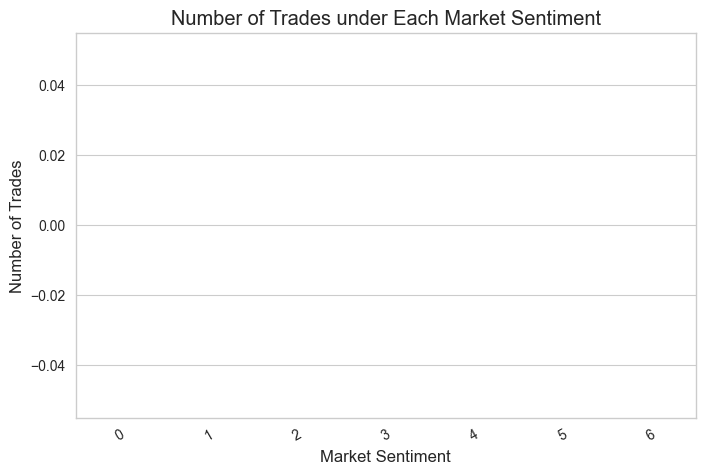

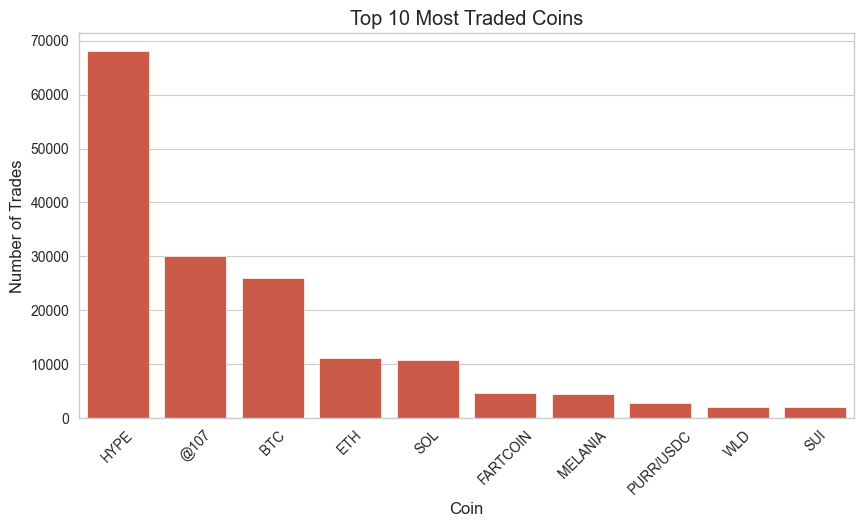

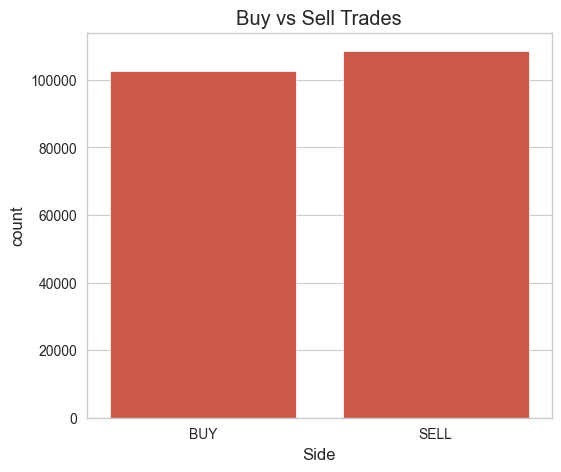

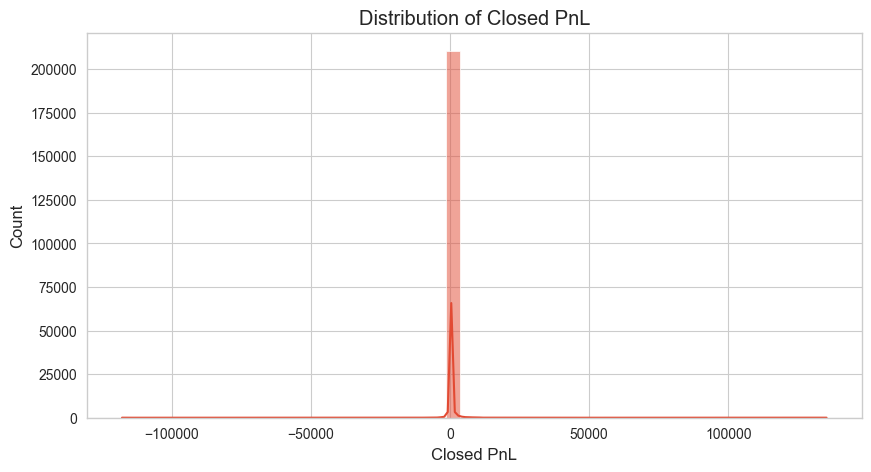

ValueError: List of boxplot statistics and `positions` values must have same the length

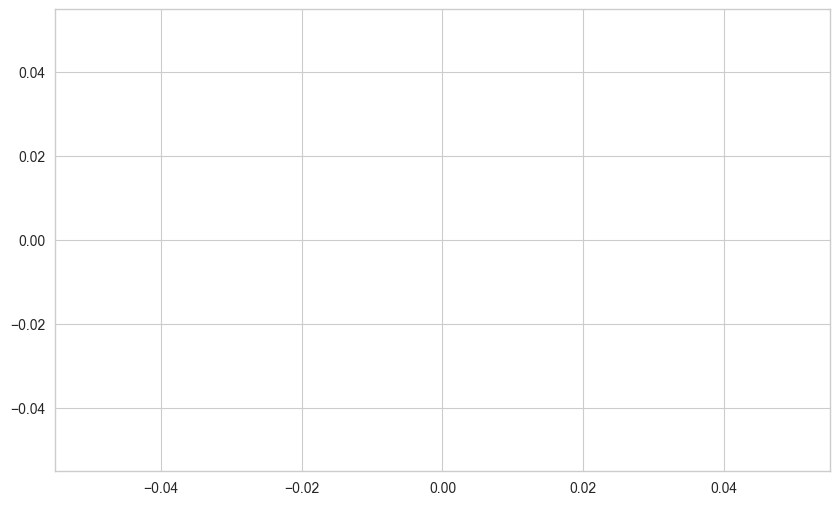

In [3]:
# ==========================================================
# PART 2 : EXPLORATORY DATA ANALYSIS
# ==========================================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (10,6)

# ---------------------------------------------------------
# 1. DATASET OVERVIEW
# ---------------------------------------------------------

print("Shape :", merged.shape)

print("\nColumns:\n")
print(merged.columns)

print("\nFirst Five Rows")
display(merged.head())

# ---------------------------------------------------------
# 2. SENTIMENT DISTRIBUTION
# ---------------------------------------------------------

plt.figure(figsize=(8,5))

sns.countplot(
    data=merged,
    x="Sentiment",
    order=merged["Sentiment"].value_counts().index
)

plt.title("Number of Trades under Each Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")
plt.xticks(rotation=30)
plt.show()

# ---------------------------------------------------------
# 3. COIN DISTRIBUTION
# ---------------------------------------------------------

top_coins = merged["Coin"].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_coins.index,
    y=top_coins.values
)

plt.title("Top 10 Most Traded Coins")
plt.xlabel("Coin")
plt.ylabel("Number of Trades")
plt.xticks(rotation=45)
plt.show()

# ---------------------------------------------------------
# 4. BUY VS SELL
# ---------------------------------------------------------

plt.figure(figsize=(6,5))

sns.countplot(
    data=merged,
    x="Side"
)

plt.title("Buy vs Sell Trades")
plt.show()

# ---------------------------------------------------------
# 5. CLOSED PNL DISTRIBUTION
# ---------------------------------------------------------

plt.figure(figsize=(10,5))

sns.histplot(
    merged["Closed PnL"],
    bins=50,
    kde=True
)

plt.title("Distribution of Closed PnL")
plt.xlabel("Closed PnL")
plt.show()

# ---------------------------------------------------------
# 6. PNL BY SENTIMENT
# ---------------------------------------------------------

plt.figure(figsize=(10,6))

sns.boxplot(
    data=merged,
    x="Sentiment",
    y="Closed PnL"
)

plt.title("PnL Distribution Across Sentiments")
plt.xticks(rotation=30)
plt.show()

# ---------------------------------------------------------
# 7. AVERAGE PNL BY SENTIMENT
# ---------------------------------------------------------

avg_pnl = merged.groupby("Sentiment")["Closed PnL"].mean().sort_values()

print("\nAverage Closed PnL")
print(avg_pnl)

plt.figure(figsize=(8,5))

avg_pnl.plot(kind="bar")

plt.title("Average Closed PnL by Sentiment")
plt.ylabel("Average PnL")
plt.show()

# ---------------------------------------------------------
# 8. MEDIAN PNL
# ---------------------------------------------------------

median_pnl = merged.groupby("Sentiment")["Closed PnL"].median()

print("\nMedian Closed PnL")
print(median_pnl)

# ---------------------------------------------------------
# 9. WIN RATE
# ---------------------------------------------------------

merged["Win"] = merged["Closed PnL"] > 0

win_rate = merged.groupby("Sentiment")["Win"].mean()*100

print("\nWin Rate (%)")
print(win_rate)

plt.figure(figsize=(8,5))

win_rate.plot(kind="bar")

plt.title("Win Rate by Market Sentiment")
plt.ylabel("Win Rate (%)")
plt.show()

# ---------------------------------------------------------
# 10. TOTAL PNL
# ---------------------------------------------------------

total_pnl = merged.groupby("Sentiment")["Closed PnL"].sum()

print("\nTotal PnL")
print(total_pnl)

plt.figure(figsize=(8,5))

total_pnl.plot(kind="bar")

plt.title("Total Profit by Sentiment")
plt.ylabel("Total Closed PnL")
plt.show()

# ---------------------------------------------------------
# 11. FEE DISTRIBUTION
# ---------------------------------------------------------

plt.figure(figsize=(10,5))

sns.histplot(
    merged["Fee"],
    bins=40,
    kde=True
)

plt.title("Fee Distribution")
plt.show()

# ---------------------------------------------------------
# 12. SIZE USD DISTRIBUTION
# ---------------------------------------------------------

plt.figure(figsize=(10,5))

sns.histplot(
    merged["Size USD"],
    bins=40,
    kde=True
)

plt.title("Trade Size Distribution (USD)")
plt.show()

# ---------------------------------------------------------
# 13. TOP 10 PROFITABLE COINS
# ---------------------------------------------------------

coin_profit = merged.groupby("Coin")["Closed PnL"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=coin_profit.index,
    y=coin_profit.values
)

plt.title("Top 10 Coins by Total Profit")
plt.xticks(rotation=45)
plt.show()

print("\nTop Profitable Coins")
print(coin_profit)

# ---------------------------------------------------------
# 14. TOP 10 LOSS MAKING COINS
# ---------------------------------------------------------

coin_loss = merged.groupby("Coin")["Closed PnL"].sum().sort_values().head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=coin_loss.index,
    y=coin_loss.values
)

plt.title("Top Loss Making Coins")
plt.xticks(rotation=45)
plt.show()

print("\nTop Loss Coins")
print(coin_loss)

# ---------------------------------------------------------
# 15. SAVE EDA SUMMARY
# ---------------------------------------------------------

eda_summary = merged.groupby("Sentiment").agg({

    "Closed PnL":["mean","median","sum"],

    "Fee":"mean",

    "Size USD":"mean"

})

print("\nEDA SUMMARY")
display(eda_summary)

print("\nPART 2 COMPLETED SUCCESSFULLY")

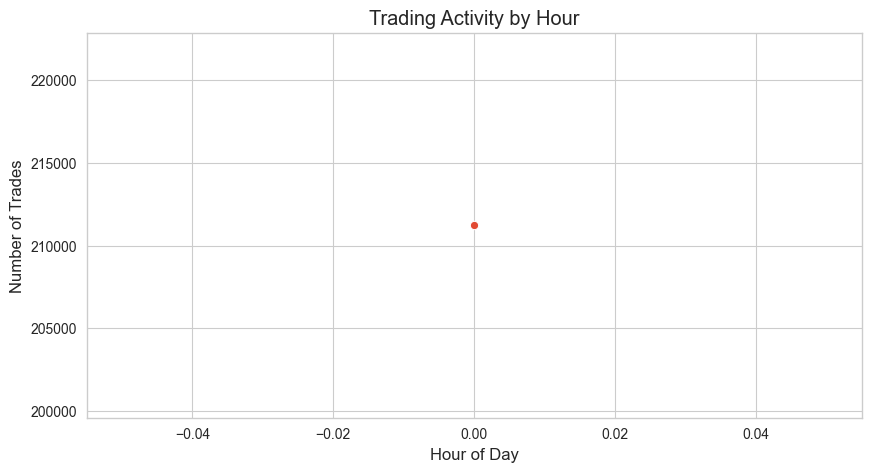

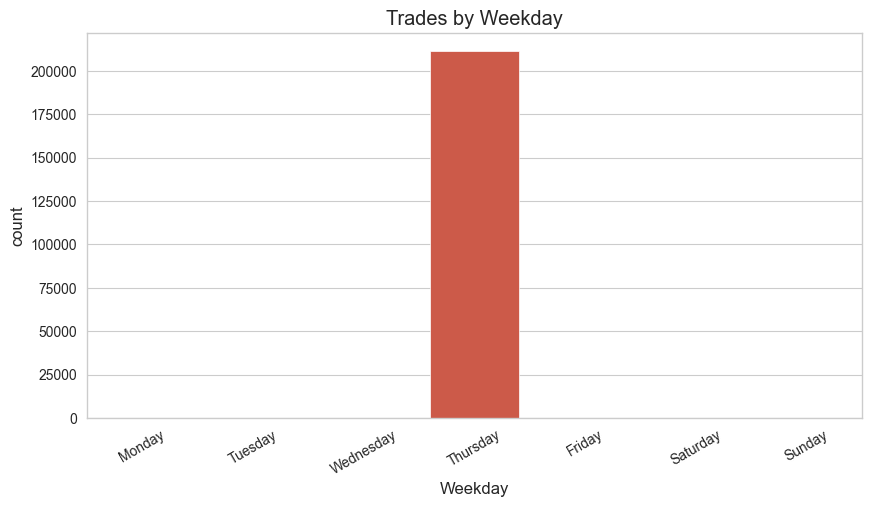

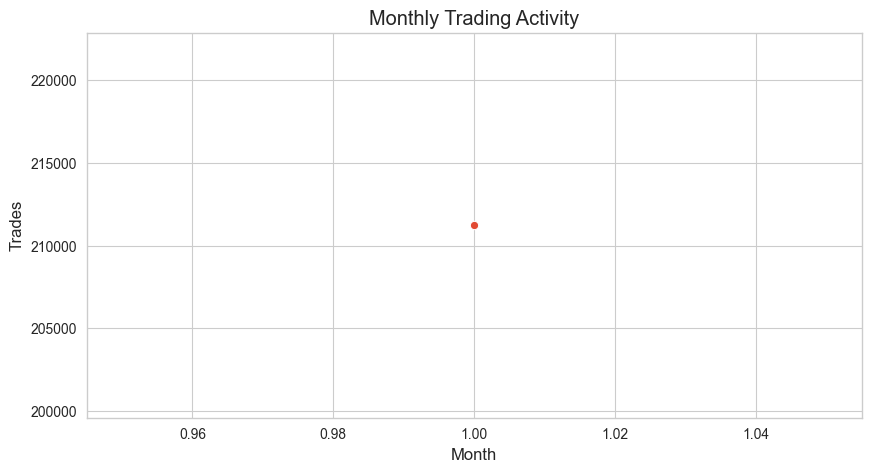

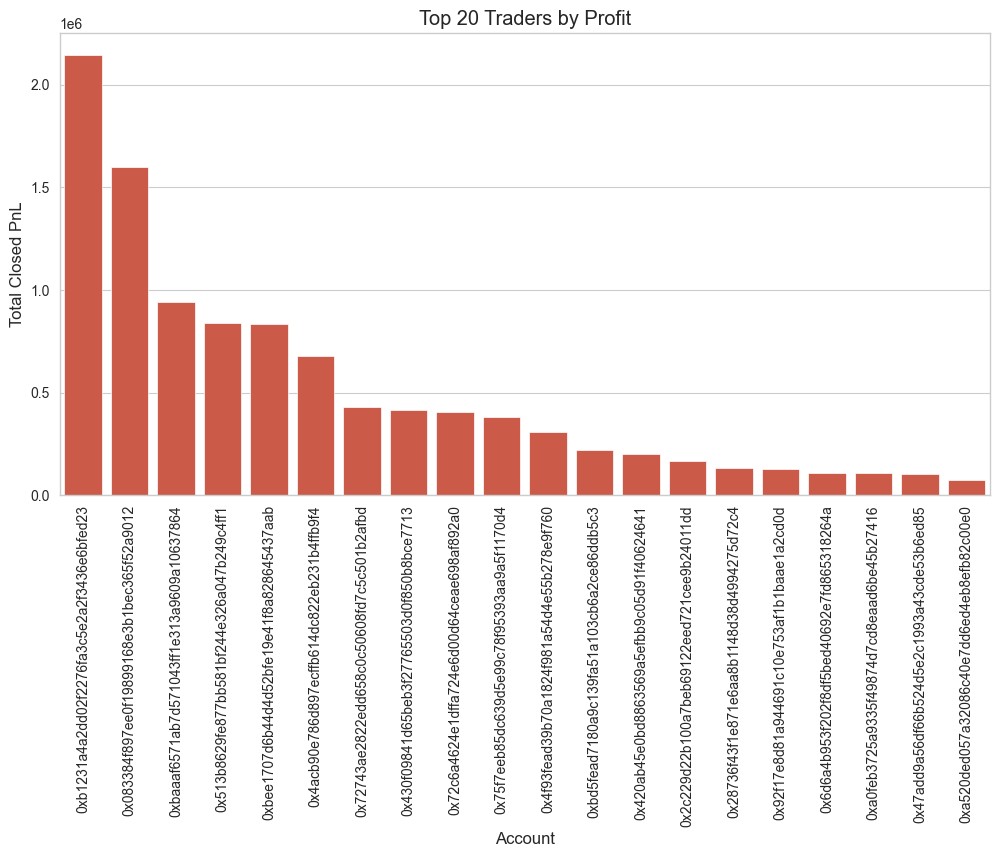

Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.165419e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    4.030115e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    3.790954e+05
0x4f93fead39b70a1824f981a54d4e55b278e9f760    3.089759e+05
0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3    2.205191e+05
0x420ab45e0bd8863569a5efbb9c05d91f40624641    1.995056e+05
0x2c229d22b100a7beb69122eed721cee9b24011dd    1.686580e+05
0x28736f43f1e871e6aa8b1148d38d4994275d72c4    1.324648e+05
0x92f17e8d81a944691c10e753af1b1baae1a2cd0d    1.265789e+05
0x6d6a4b953f202f8df5bed40692e7fd865318264a    1.

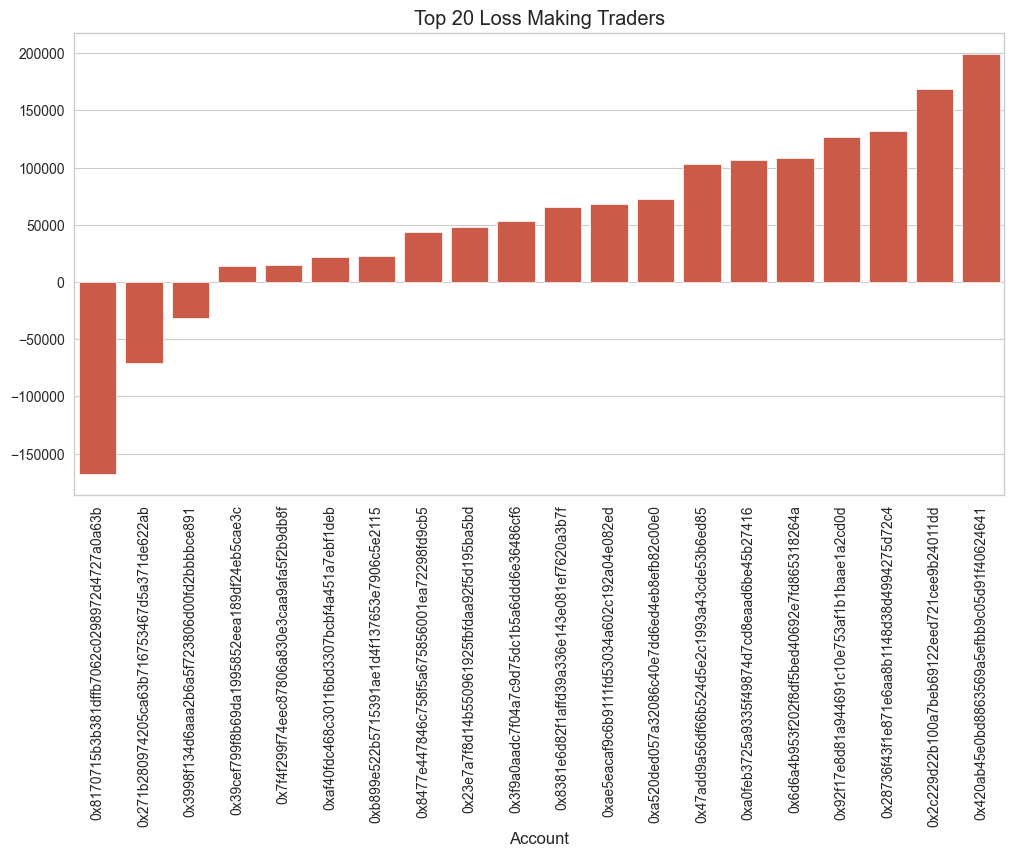

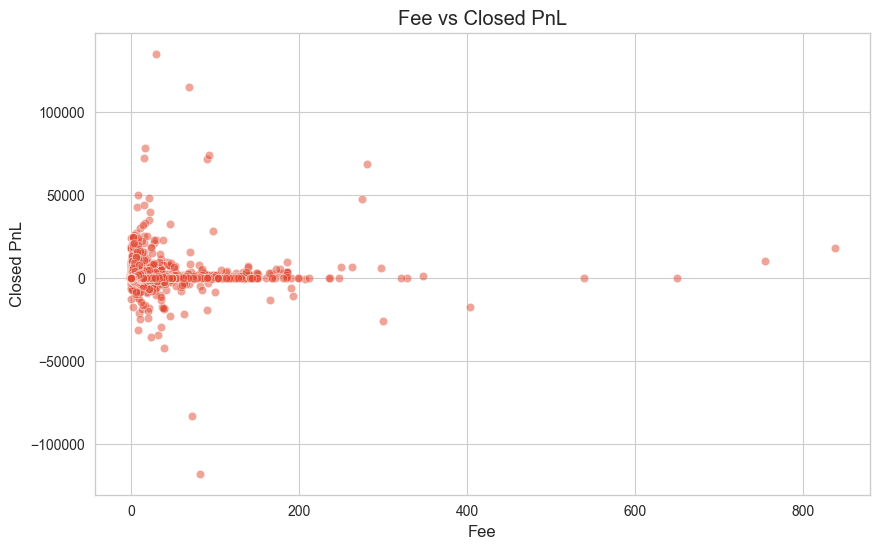

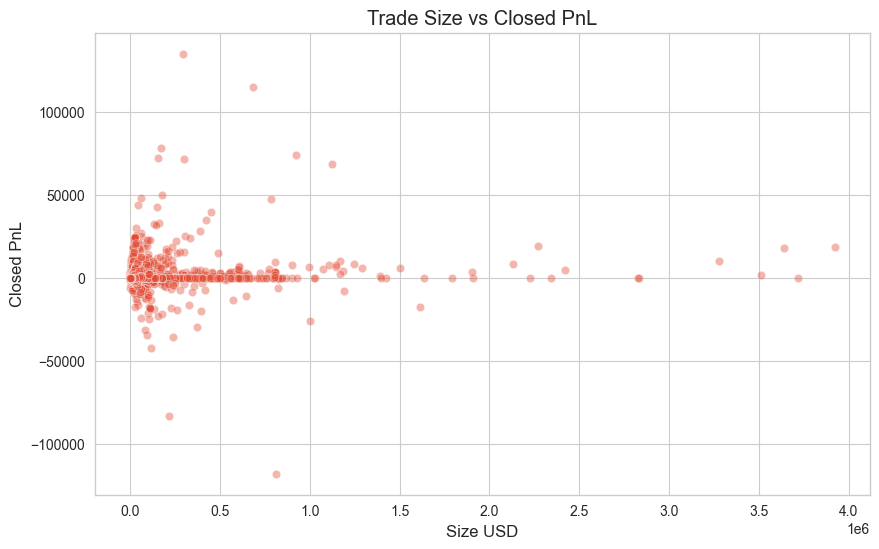

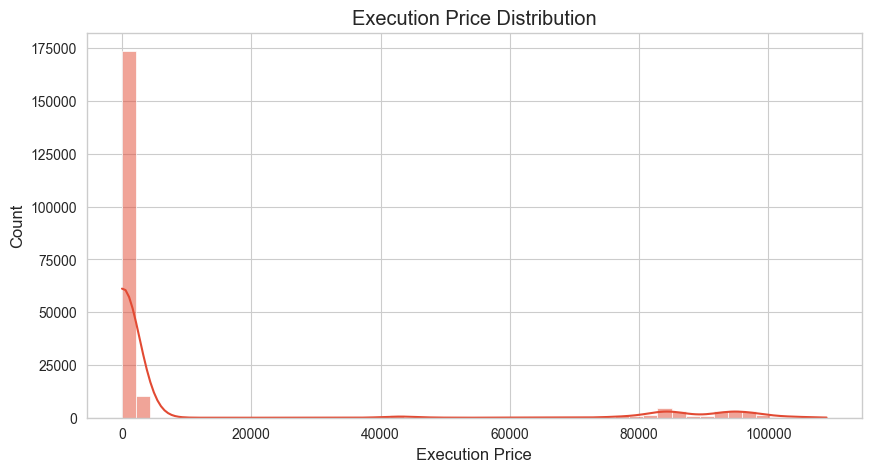

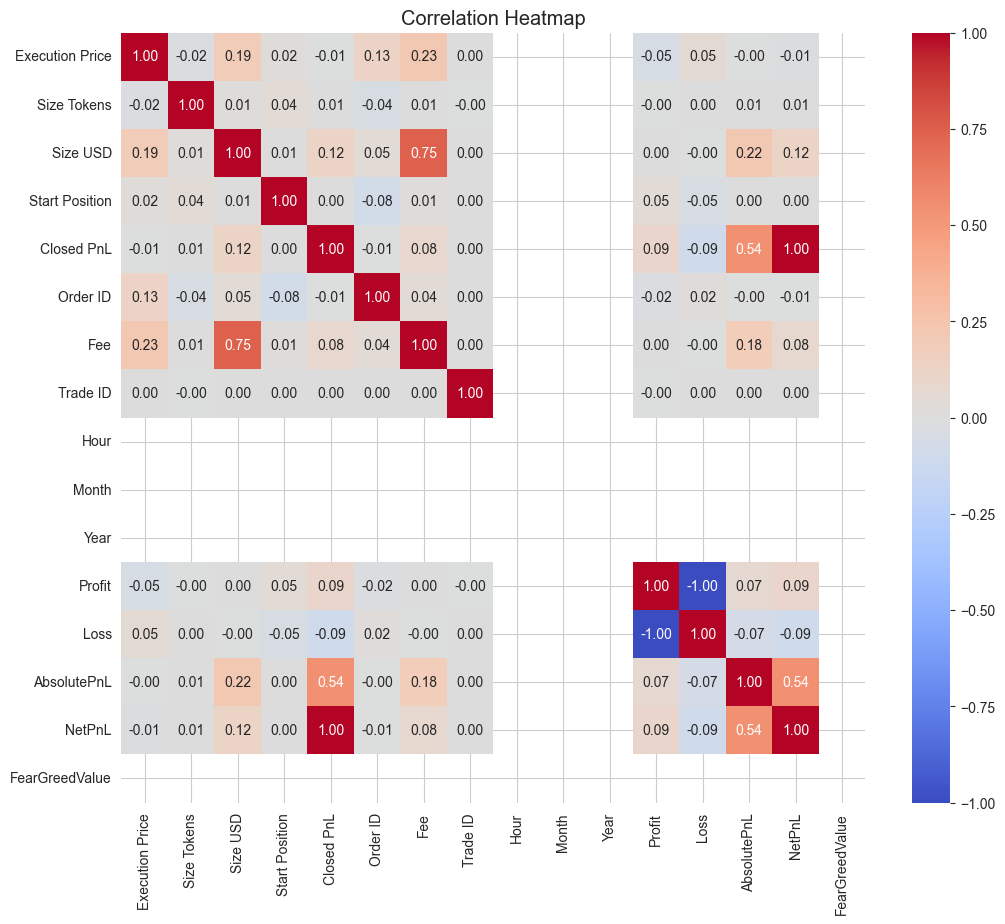

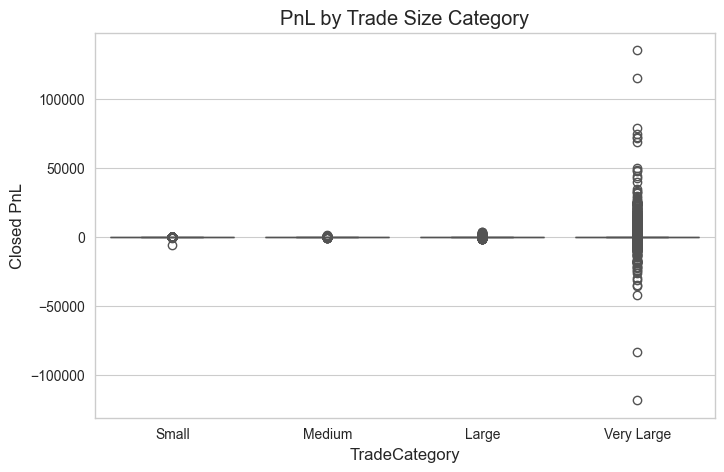

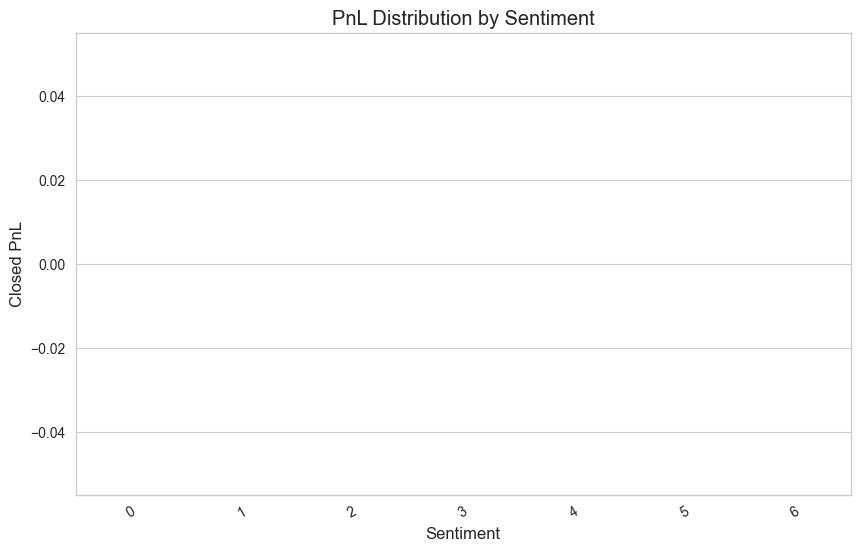


Average Profit by Side
Side
BUY     36.104730
SELL    60.713803
Name: Closed PnL, dtype: float64


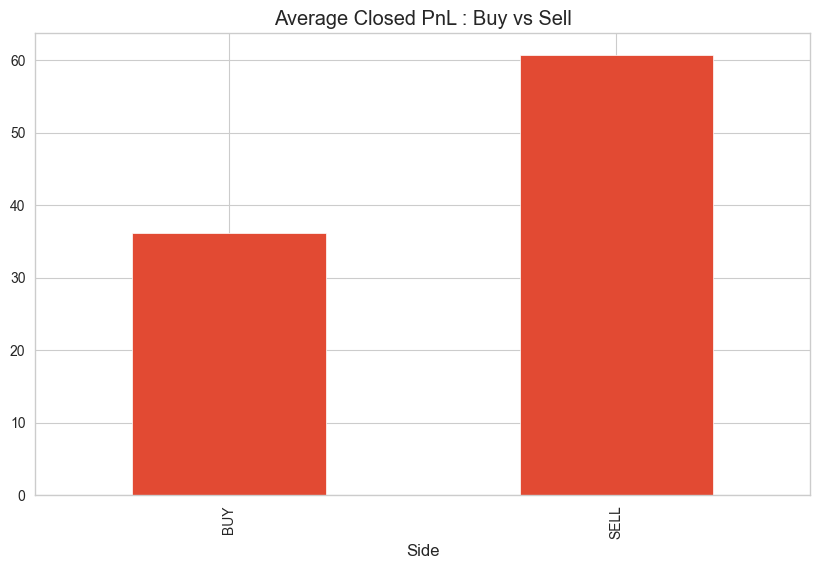

Empty DataFrame
Columns: [Sentiment, Coin, Closed PnL]
Index: []

T-Test Result
T Statistic : nan
P Value : nan
Difference is NOT statistically significant


Empty DataFrame
Columns: [(Closed PnL, count), (Closed PnL, mean), (Closed PnL, median), (Closed PnL, std), (Closed PnL, sum), (Fee, mean), (Fee, sum), (Size USD, mean), (Size USD, max)]
Index: []


PART 3 COMPLETED


In [4]:
# ==========================================================
# PART 3 : ADVANCED EDA
# ==========================================================

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
import numpy as np

plt.rcParams["figure.figsize"] = (10,6)

# ---------------------------------------------------------
# 1. HOURLY TRADING ACTIVITY
# ---------------------------------------------------------

hourly = merged.groupby("Hour").size()

plt.figure(figsize=(10,5))
sns.lineplot(x=hourly.index, y=hourly.values, marker="o")
plt.title("Trading Activity by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trades")
plt.grid(True)
plt.show()

# ---------------------------------------------------------
# 2. WEEKDAY ANALYSIS
# ---------------------------------------------------------

weekday_order = [
    "Monday","Tuesday","Wednesday",
    "Thursday","Friday","Saturday","Sunday"
]

plt.figure(figsize=(10,5))

sns.countplot(
    data=merged,
    x="Weekday",
    order=weekday_order
)

plt.title("Trades by Weekday")
plt.xticks(rotation=30)
plt.show()

# ---------------------------------------------------------
# 3. MONTHLY TRADES
# ---------------------------------------------------------

monthly = merged.groupby("Month").size()

plt.figure(figsize=(10,5))

sns.lineplot(
    x=monthly.index,
    y=monthly.values,
    marker="o"
)

plt.title("Monthly Trading Activity")
plt.xlabel("Month")
plt.ylabel("Trades")
plt.show()

# ---------------------------------------------------------
# 4. TOP 20 TRADERS
# ---------------------------------------------------------

top_traders = (
    merged.groupby("Account")["Closed PnL"]
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_traders.index,
    y=top_traders.values
)

plt.xticks(rotation=90)
plt.title("Top 20 Traders by Profit")
plt.ylabel("Total Closed PnL")
plt.show()

print(top_traders)

# ---------------------------------------------------------
# 5. TOP 20 LOSS MAKERS
# ---------------------------------------------------------

loss_traders = (
    merged.groupby("Account")["Closed PnL"]
    .sum()
    .sort_values()
    .head(20)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=loss_traders.index,
    y=loss_traders.values
)

plt.xticks(rotation=90)
plt.title("Top 20 Loss Making Traders")
plt.show()

# ---------------------------------------------------------
# 6. FEE VS PROFIT
# ---------------------------------------------------------

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=merged,
    x="Fee",
    y="Closed PnL",
    alpha=0.5
)

plt.title("Fee vs Closed PnL")
plt.show()

# ---------------------------------------------------------
# 7. TRADE SIZE VS PROFIT
# ---------------------------------------------------------

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=merged,
    x="Size USD",
    y="Closed PnL",
    alpha=0.4
)

plt.title("Trade Size vs Closed PnL")
plt.show()

# ---------------------------------------------------------
# 8. EXECUTION PRICE DISTRIBUTION
# ---------------------------------------------------------

plt.figure(figsize=(10,5))

sns.histplot(
    merged["Execution Price"],
    bins=50,
    kde=True
)

plt.title("Execution Price Distribution")
plt.show()

# ---------------------------------------------------------
# 9. CORRELATION HEATMAP
# ---------------------------------------------------------

numeric = merged.select_dtypes(include=np.number)

corr = numeric.corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

# ---------------------------------------------------------
# 10. PNL BY TRADE CATEGORY
# ---------------------------------------------------------

plt.figure(figsize=(8,5))

sns.boxplot(
    data=merged,
    x="TradeCategory",
    y="Closed PnL"
)

plt.title("PnL by Trade Size Category")
plt.show()

# ---------------------------------------------------------
# 11. VIOLIN PLOT
# ---------------------------------------------------------

plt.figure(figsize=(10,6))

sns.violinplot(
    data=merged,
    x="Sentiment",
    y="Closed PnL"
)

plt.xticks(rotation=30)
plt.title("PnL Distribution by Sentiment")
plt.show()

# ---------------------------------------------------------
# 12. BUY VS SELL PROFIT
# ---------------------------------------------------------

buy_sell = (
    merged.groupby("Side")["Closed PnL"]
    .mean()
)

print("\nAverage Profit by Side")
print(buy_sell)

buy_sell.plot(kind="bar")
plt.title("Average Closed PnL : Buy vs Sell")
plt.show()

# ---------------------------------------------------------
# 13. TOP COINS UNDER EACH SENTIMENT
# ---------------------------------------------------------

coin_sentiment = (
    merged.groupby(["Sentiment","Coin"])["Closed PnL"]
    .sum()
    .reset_index()
)

print(coin_sentiment.head(20))

# ---------------------------------------------------------
# 14. STATISTICAL TEST
# ---------------------------------------------------------

fear = merged[
    merged["Sentiment"].str.contains("Fear", na=False)
]["Closed PnL"]

greed = merged[
    merged["Sentiment"].str.contains("Greed", na=False)
]["Closed PnL"]

t_stat, p_value = ttest_ind(
    fear,
    greed,
    nan_policy="omit"
)

print("\nT-Test Result")
print("T Statistic :", t_stat)
print("P Value :", p_value)

if p_value < 0.05:
    print("Difference is statistically significant")
else:
    print("Difference is NOT statistically significant")

# ---------------------------------------------------------
# 15. SUMMARY TABLE
# ---------------------------------------------------------

summary = merged.groupby("Sentiment").agg({

    "Closed PnL":["count","mean","median","std","sum"],

    "Fee":["mean","sum"],

    "Size USD":["mean","max"]

})

display(summary)

print("\nPART 3 COMPLETED")

In [5]:
# ==========================================================
# PART 4 : BUSINESS INSIGHTS
# ==========================================================

print("="*60)
print("BUSINESS INSIGHTS")
print("="*60)

# ---------------------------------------------------------
# 1. BEST MARKET SENTIMENT
# ---------------------------------------------------------

avg_pnl = merged.groupby("Sentiment")["Closed PnL"].mean()

best_sentiment = avg_pnl.idxmax()

print(f"\nBest Market Sentiment : {best_sentiment}")
print(avg_pnl)

# ---------------------------------------------------------
# 2. WORST MARKET SENTIMENT
# ---------------------------------------------------------

worst_sentiment = avg_pnl.idxmin()

print(f"\nWorst Market Sentiment : {worst_sentiment}")

# ---------------------------------------------------------
# 3. WIN RATE
# ---------------------------------------------------------

merged["Winning Trade"] = merged["Closed PnL"] > 0

win_rate = merged.groupby("Sentiment")["Winning Trade"].mean()*100

print("\nWin Rate (%)")

print(win_rate)

# ---------------------------------------------------------
# 4. TOP 10 PROFITABLE COINS
# ---------------------------------------------------------

top_coins = merged.groupby("Coin")["Closed PnL"].sum().sort_values(ascending=False)

print("\nTop 10 Coins")

print(top_coins.head(10))

# ---------------------------------------------------------
# 5. TOP 10 TRADERS
# ---------------------------------------------------------

top_accounts = merged.groupby("Account")["Closed PnL"].sum().sort_values(ascending=False)

print("\nTop Traders")

print(top_accounts.head(10))

# ---------------------------------------------------------
# 6. SIDE ANALYSIS
# ---------------------------------------------------------

side = merged.groupby("Side")["Closed PnL"].mean()

print("\nAverage Profit by Side")

print(side)

# ---------------------------------------------------------
# 7. FEE IMPACT
# ---------------------------------------------------------

fee_corr = merged["Fee"].corr(merged["Closed PnL"])

print("\nCorrelation Between Fee and Profit")

print(fee_corr)

# ---------------------------------------------------------
# 8. TRADE SIZE IMPACT
# ---------------------------------------------------------

size_corr = merged["Size USD"].corr(merged["Closed PnL"])

print("\nCorrelation Between Trade Size and Profit")

print(size_corr)

# ---------------------------------------------------------
# 9. EXECUTION PRICE IMPACT
# ---------------------------------------------------------

price_corr = merged["Execution Price"].corr(merged["Closed PnL"])

print("\nCorrelation Between Execution Price and Profit")

print(price_corr)

# ---------------------------------------------------------
# 10. SUMMARY
# ---------------------------------------------------------

summary = pd.DataFrame({

    "Metric":[
        "Total Trades",
        "Total Traders",
        "Coins",
        "Average PnL",
        "Median PnL",
        "Maximum Profit",
        "Maximum Loss"
    ],

    "Value":[

        len(merged),

        merged["Account"].nunique(),

        merged["Coin"].nunique(),

        merged["Closed PnL"].mean(),

        merged["Closed PnL"].median(),

        merged["Closed PnL"].max(),

        merged["Closed PnL"].min()

    ]

})

print(summary)

display(summary)

BUSINESS INSIGHTS


ValueError: attempt to get argmax of an empty sequence

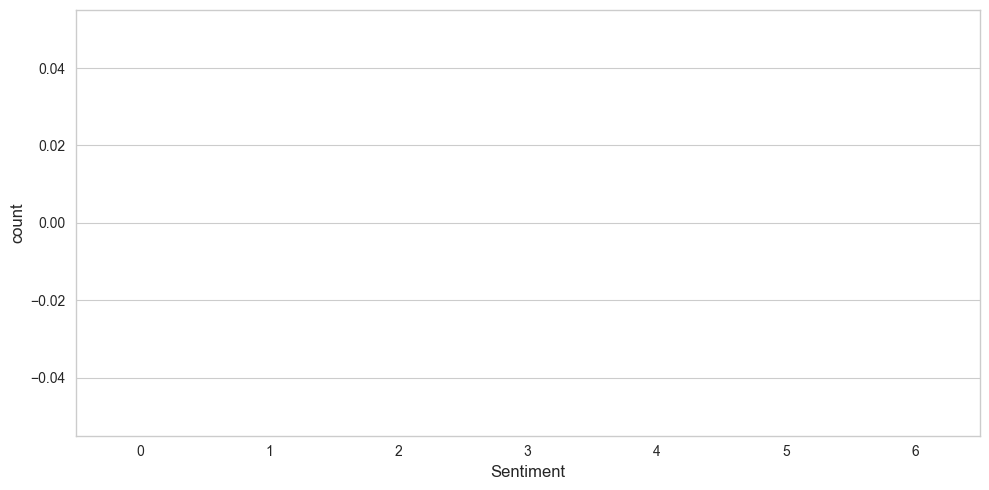

In [6]:
plt.figure(figsize=(10,5))

sns.countplot(data=merged,x="Sentiment")

plt.tight_layout()

plt.savefig("sentiment_distribution.png",dpi=300)

plt.show()

In [7]:
merged.to_csv(
    "final_dataset.csv",
    index=False
)

print("Dataset Exported Successfully")

Dataset Exported Successfully
